PREPROCESSING DATA

In [14]:
import pandas as pd

# membaca dataset
df = pd.read_csv("Training.csv")
test = pd.read_csv("Testing.csv")

# mengambil semua kolom gejala
symptoms = df.columns[:-1]

In [15]:
# memilih gejala aktif
for _, row in df.iterrows():
    disease = row['prognosis']

    for symptom in symptoms:
        if row[symptom] == 1:
            print(symptom, "->", disease)

itching -> Fungal infection
skin_rash -> Fungal infection
nodal_skin_eruptions -> Fungal infection
dischromic _patches -> Fungal infection
skin_rash -> Fungal infection
nodal_skin_eruptions -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
nodal_skin_eruptions -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
skin_rash -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
skin_rash -> Fungal infection
nodal_skin_eruptions -> Fungal infection
skin_rash -> Fungal infection
nodal_skin_eruptions -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
nodal_skin_eruptions -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
skin_rash -> Fungal infection
dischromic _patches -> Fungal infection
itching -> Fungal infection
skin_rash -> Fungal infection
nodal_skin_eruptions -> Fungal infection
itching -> Fungal infection

PEMBENTUKAN GRAF BIPARTIT

In [16]:
import networkx as nx

# membuat graf kosong
G = nx.Graph()

# menambahkan edge gejala-penyakit
for _, row in df.iterrows():
    disease = row['prognosis']

    for symptom in symptoms:
        if row[symptom] == 1:
            G.add_edge(symptom, disease)

In [17]:
# cek graf
print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())

Jumlah node: 172
Jumlah edge: 321


ANALISIS DEGREE

In [18]:
# menghitung degree semua node
degrees = dict(G.degree())

In [19]:
# top node dengan degree tertinggi
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)

print(top_nodes[:3])

[('vomiting', 17), ('fatigue', 17), ('Common Cold', 17)]


In [20]:
# top gejala
top_symptoms = [
    (node, deg)
    for node, deg in top_nodes
    if node in symptoms
]

print(top_symptoms[:3])

[('vomiting', 17), ('fatigue', 17), ('high_fever', 12)]


In [21]:
# top penyakit
diseases = df['prognosis'].unique()

top_diseases = [
    (node, deg)
    for node, deg in top_nodes
    if node in diseases
]

print(top_diseases[:3])

[('Common Cold', 17), ('Tuberculosis', 16), ('Dengue', 14)]


VISUALISASI DATA DAN ANALISIS GRAF


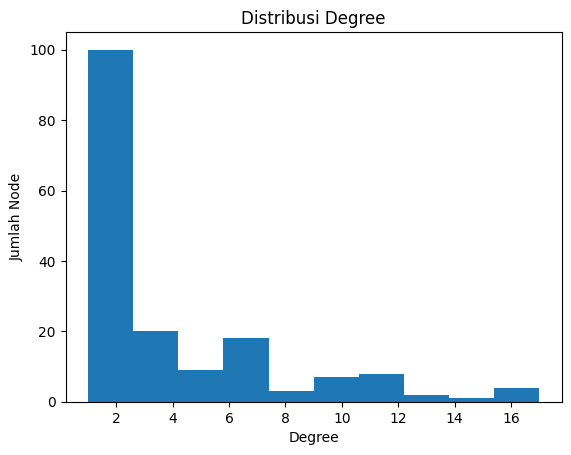

In [22]:
import matplotlib.pyplot as plt
# histogram distribusi degree
degree_values = list(degrees.values())

plt.hist(degree_values)
plt.xlabel("Degree")
plt.ylabel("Jumlah Node")
plt.title("Distribusi Degree")
plt.show()

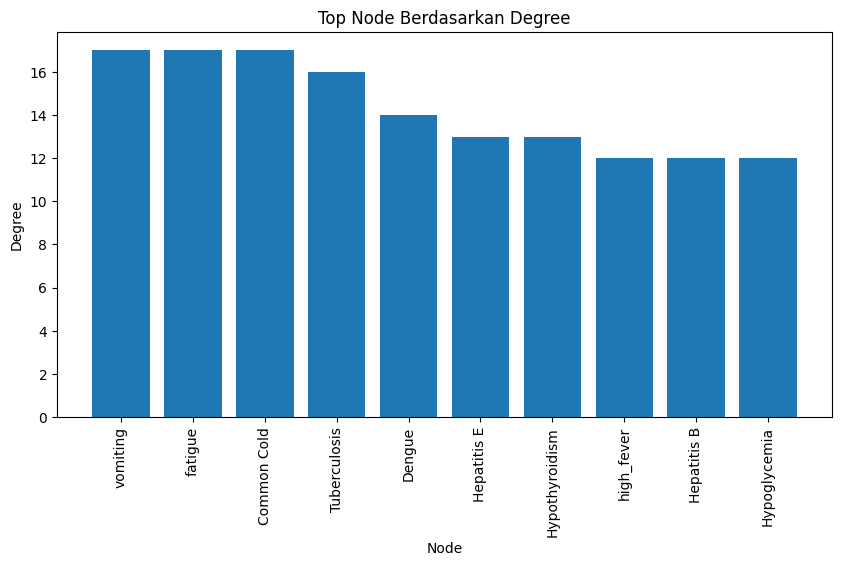

In [23]:
# top node tertinggi
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)

nodes = [x[0] for x in top_nodes[:10]]
values = [x[1] for x in top_nodes[:10]]

plt.figure(figsize=(10,5))
plt.bar(nodes, values)
plt.xticks(rotation=90)
plt.xlabel("Node")
plt.ylabel("Degree")
plt.title("Top Node Berdasarkan Degree")
plt.show()

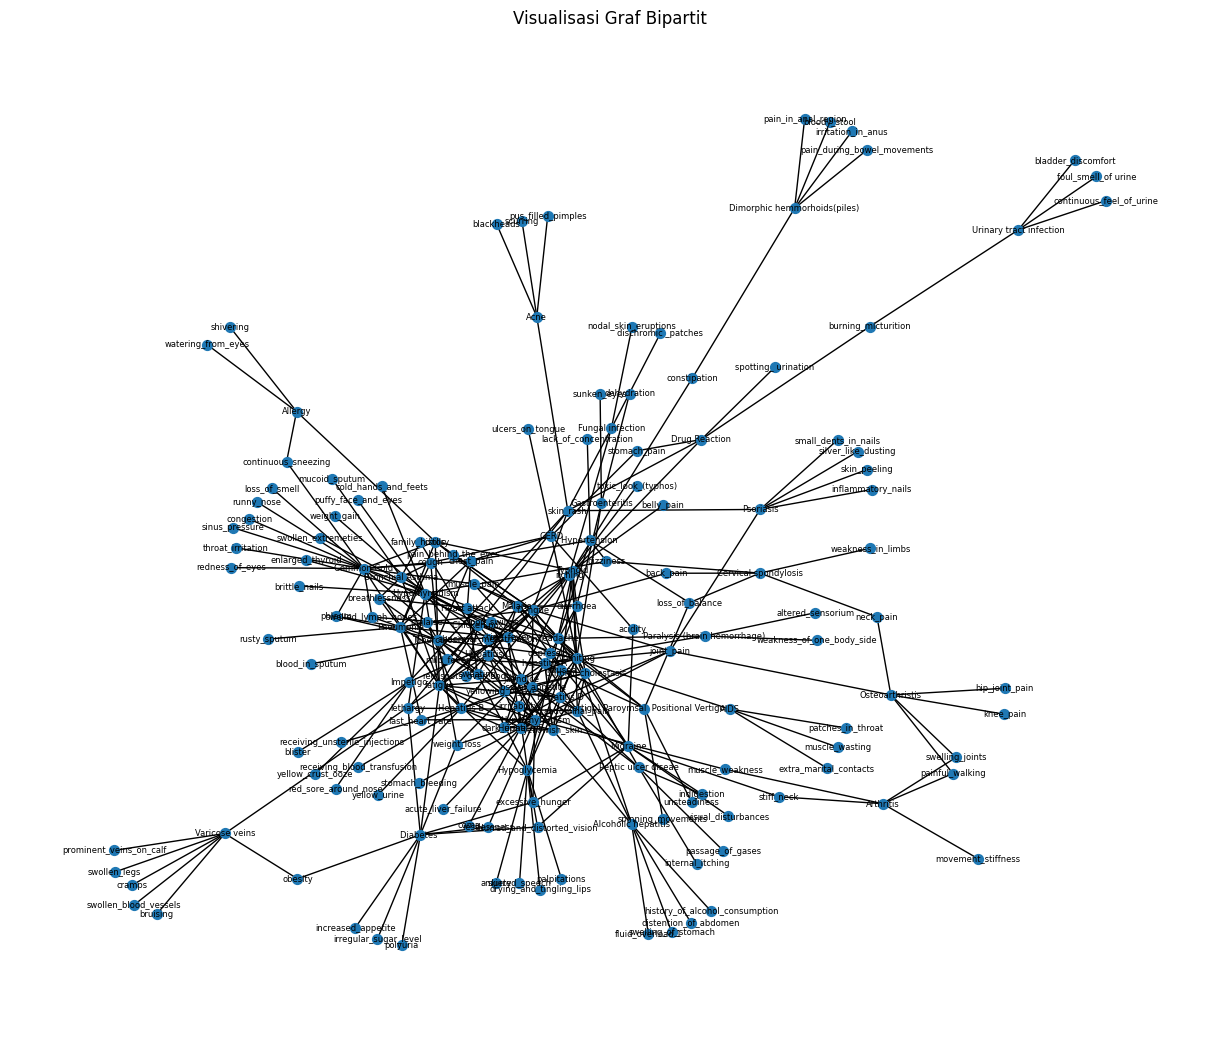

In [24]:
# visualisasi graf bipartit
plt.figure(figsize=(12,10))

nx.draw(
    G,
    with_labels=True,
    node_size=50,
    font_size=6
)

plt.title("Visualisasi Graf Bipartit")
plt.show()